[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**
Definimos $x_i$ como la cantidad en kg del ingrediente $i$ a incluir en la mezcla. Para $i$ en {1,2,3,4,5,6} sean (Maíz, Soya, Heno, Melaza, Minerales, Salvado)
$$x=[x_1, x_2, x_3, x_4, x_5, x_6]^T $$

**Funcion objetivo:**
Queremos minimizar el costo total de la mezcla, donde $c_i$ es el costo por kilogramo de cada ingrediente
$${\text{min}} f(x) = \sum_{i=1}^6 c_ix_i$$

**Restricciones:**

$$\sum_{i=1}^{6} n_{ij} x_i \ge R_j, \quad \forall j \in {\text{Energía, Proteína, Calcio, Fósforo}} $$
$$ 8 \le \sum_{i=1}^{6} x_i \le 12 $$
$$ 0 \le x_i \le \text{Max}_i, \quad \forall i \in {1, \dots, 6}$$

### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
Se elige scipy.optimize.linprog

**Justificacion (2-3 oraciones):**
Tanto la función objetivo como todas las restricciones son lineales, lo que permite usar este método exacto y eficiente.

In [2]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [4]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    """Calcula el costo total de la dieta.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        float -- costo total de la dieta
    """
    return np.dot(costos_p1,x) # Dado el array de costos


def verificar_p1(x):
    """Verifica si la solucion cumple TODAS las restricciones.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        dict con:
            'factible': bool
            'nutrientes_totales': np.array (4,) -- aporte total de cada nutriente
            'intake_total': float -- kg totales
    """
    # Calcular aporte total de nutrientes (matrix @ vector)
    nutrientes_totales = nutrientes_p1 @ x

    # Calcular peso total (que sería el intake)
    intake_total = np.sum(x)

    # Validar que tenga los nutrientes mínimos
    c1 = np.all(nutrientes_totales >= req_min_p1)

    # Validar el peso total
    c2 = (intake_min_p1 <= intake_total) and (intake_total <= intake_max_p1)

    # Respetar maximo de cada ingrediente y si es positivo
    c3 = np.all(x >= 0) and np.all(x <= max_kg_p1)

    factible = c1 and c2 and c3

    return {'factible': factible,
            'nutrientes_totales': nutrientes_totales,
            'intake_total': intake_total
            }

def resolver_p1():
    """Resuelve el problema de nutricion animal.

    Usa los datos globales (costos_p1, nutrientes_p1, etc.)
    y el optimizador que elegiste en la seccion 1.2.

    Returns:
        x_opt: np.array (6,) -- kg optimos de cada ingrediente
        costo_opt: float -- costo minimo
    """
    # Coefcieintes de la función objetivo -> los costos
    c = costos_p1

    # Restricción de nutrientes
    A_nut = -nutrientes_p1
    b_nut = -req_min_p1

    # Restriccion de consumo máximo
    A_max = np.ones((1,6))
    b_max = np.array(intake_max_p1)

    # Restricción consumo mínimo
    A_min = -np.ones((1,6))
    b_min = np.array(-intake_min_p1)

    # Unir todas las restricciones
    A = np.vstack((A_nut, A_max, A_min))
    b = np.hstack((b_nut, b_max, b_min))

    # Bounds: cada x_i va de 0 hasta su max_kg_p1 correspondiente
    bounds = [(0, max_kg) for max_kg in max_kg_p1]

    # Ejecutar el optimizador linprog con highs
    respuesta = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    if respuesta.success:
      return respuesta.x, respuesta.fun
    else:
      raise ValueError(f"Error en la optimización: {respuesta.message}")

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


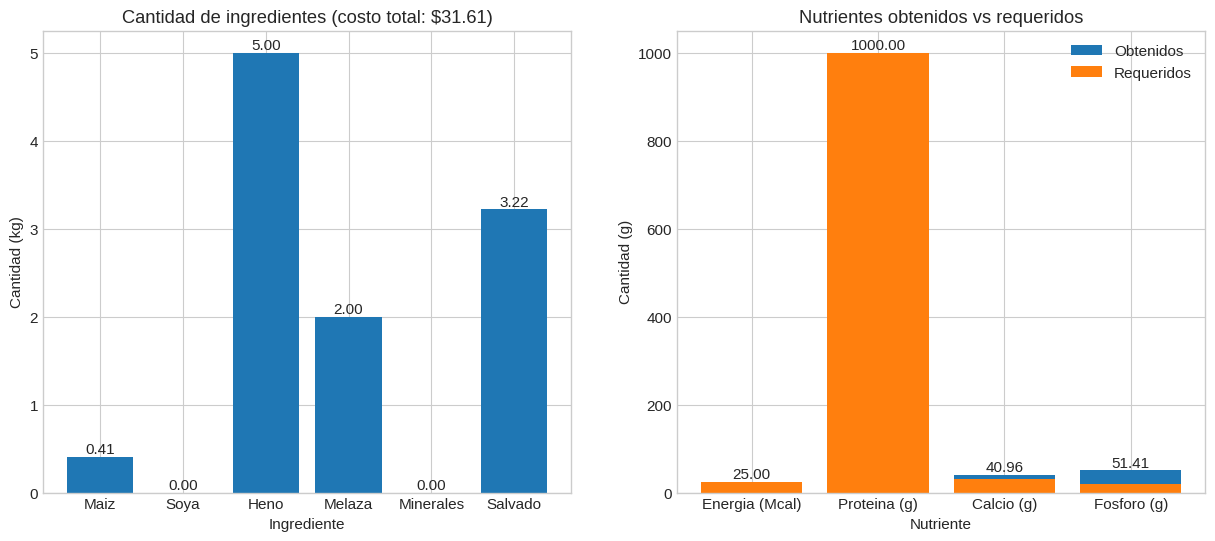

In [5]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    Debe mostrar:
    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos

    Args:
        x_opt: np.array (6,)
        costo_opt: float
    """
    fig, ax = plt.subplots(1, 2, figsize=(15,6))

    # Panel 1 para la cantidad de ingredientes
    ax[0].bar(nombres_p1, x_opt)
    ax[0].set_title(f"Cantidad de ingredientes (costo total: ${costo_opt:.2f})")
    ax[0].set_ylabel("Cantidad (kg)")
    ax[0].set_xlabel("Ingrediente")
    for i, v in enumerate(x_opt):
      ax[0].text(i, v, f"{v:.2f}", ha='center', va='bottom')

    # Panel 2 para los nutrientes
    nutrientes_obtenidos = nutrientes_p1 @ x_opt
    indices = np.arange(len(nombres_nutrientes_p1))
    ax[1].bar(indices, nutrientes_obtenidos, label="Obtenidos")
    ax[1].bar(indices, req_min_p1, label="Requeridos")
    ax[1].set_title("Nutrientes obtenidos vs requeridos")
    ax[1].set_ylabel("Cantidad (g)")
    ax[1].set_xlabel("Nutriente")
    ax[1].set_xticks(indices)
    ax[1].set_xticklabels(nombres_nutrientes_p1)
    ax[1].legend()
    for i, v in enumerate(nutrientes_obtenidos):
      ax[1].text(i, v, f"{v:.2f}", ha='center', va='bottom')

# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**
Definimos $w$ como el vector de pesos de capital asignados a cada uno de los 5 objetivos en donde cada $w_i$ es el porcentaje invertido en el activo i
$$w = [w_1, w_2,w_3,w_4,w_5]^T$$

**Funcion objetivo:**
Queremosm minimizar el riesgo del portafolio representado por la varianza del rendimiento. Sea $\sum$ la matriz de covarianza
$$ \text{min} f(w) = w^T\sum w $$

**Restricciones:**

$$ \sum_{i=1}^{5} r_i w_i \ge 0.08$$  $$\text{(Rendimiento mínimo esperado)} $$

$$\sum_{i=1}^{5} w_i = 1$$
$$ \text{(Presupuesto total invertido)} $$

$$ 0 \le w_i \le 0.40, \quad \forall i \in {1, \dots, 5} $$
$$ \text{(Sin ventas en corto y límite por activo)}$$

### 2.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
Se elige utilizar scipy.optimize.minimize con el método L-BFGS-B

**Justificacion (2-3 oraciones):**
Este es un problema con función suave no lineal pero sí convexa que permite incluir restricciones de igualdad y desgualdad con cotas. En este caso la suma de los pesos es una igualdad, el rendimiento mínimo es una desigualdad y las cotas son los límites por activo.

In [6]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [16]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Calcula la varianza (riesgo) del portafolio.

    Args:
        w: np.array (5,) -- proporcion invertida en cada activo

    Returns:
        float -- varianza del portafolio
    """
    return w.T @ cov_p2 @ w # varianza del portafolio


def verificar_p2(w):
    """Verifica si el portafolio cumple todas las restricciones.

    Args:
        w: np.array (5,) -- proporciones

    Returns:
        dict con:
            'factible': bool
            'rendimiento': float -- rendimiento esperado del portafolio
            'varianza': float
            'suma_pesos': float
    """
    # Calcular rendimiento, varianza, suma_persos
    rendimiento = np.dot(rendimientos_p2,w)
    varianza = objetivo_p2(w)
    suma_pesos = np.sum(w)

    # Calcular si el rendimiento es el esperado
    c1 = rendimiento >= retorno_minimo_p2

    # Calcular si la suma de pesos es 1
    c2 = np.isclose(suma_pesos, 1.0)

    # Revisar si los pesos están entre 0 y 0.40
    c3 = np.all(w >= 0) and np.all(w <= max_por_activo_p2)

    factible = c1 and c2 and c3

    return {
        'factible': factible,
        'rendimiento': rendimiento,
        'varianza': varianza,
        'suma_pesos': suma_pesos
    }


def resolver_p2():
    """Resuelve el problema de portafolio.

    Returns:
        w_opt: np.array (5,) -- proporciones optimas
        varianza_opt: float -- varianza minima
    """
    # Se da un punto inicial con distribución equitativa (0.20 cada uno)
    w0 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

    # Restricciones de scipy.optimize.minimize
    cons = [
        # Pesos igual a 1
        {'type':'eq', 'fun': lambda w: np.sum(w) - 1.0},
        # Rendimiento  - 0.08 igual o mayor a 0
        {'type':'ineq','fun': lambda w: np.dot(rendimientos_p2,w) - retorno_minimo_p2},
    ]

    # Cotas por activo
    bounds = [(0, max_por_activo_p2) for _ in range(5)]

    respuesta = minimize(objetivo_p2, w0, method = 'SLSQP', bounds=bounds, constraints=cons)

    if respuesta.success:
      return respuesta.x, respuesta.fun
    else:
      raise
      ValueError(f"Error en la optimización: {respuesta.message}")

Solucion P2:
  Bonos gob.: 35.7%
  Acciones tech: 9.9%
  Bienes raices: 27.4%
  Materias primas: 19.4%
  Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Factible: True


/tmp/ipython-input-344174385.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(activos_p2, rotation=45)


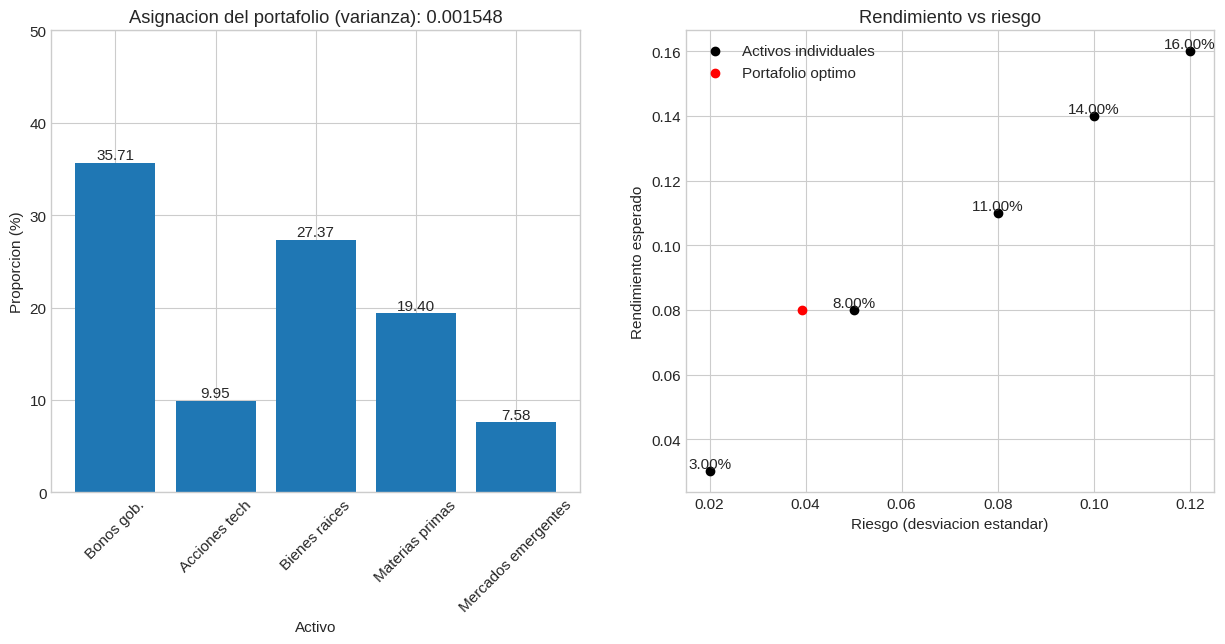

In [17]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio.

    Debe mostrar:
    - Panel 1: Barras con la asignacion del portafolio (% por activo)
    - Panel 2: Rendimiento vs riesgo del portafolio optimo

    Args:
        w_opt: np.array (5,)
        varianza_opt: float
    """
    fig, ax = plt.subplots(1, 2, figsize=(15,6))

    # Convertir a porcentaje
    w_opt_p2 = w_opt * 100

    # Panel 1: barras con asignación del portafolio
    ax[0].bar(activos_p2, w_opt_p2)
    ax[0].set_title(f"Asignacion del portafolio (varianza): {varianza_opt:.6f}")
    ax[0].set_ylabel("Proporcion (%)")
    ax[0].set_xlabel("Activo")
    ax[0].set_ylim(0,50) # Máximo permitido es 40%
    ax[0].set_xticklabels(activos_p2, rotation=45)
    for i, v in enumerate(w_opt_p2):
      ax[0].text(i, v, f"{v:.2f}", ha='center', va='bottom')

   # Panel 2: rendimiento vs riesgo
    riesgo_individual = np.sqrt(np.diag(cov_p2))
    rendimiento_optimo = np.dot(rendimientos_p2, w_opt)
    riesgo_optimo = np.sqrt(varianza_opt)

    #Graficar
    ax[1].scatter(riesgo_individual, rendimientos_p2, color='black', label='Activos individuales')
    ax[1].scatter(riesgo_optimo, rendimiento_optimo, color='red', label='Portafolio optimo')
    ax[1].set_title("Rendimiento vs riesgo")
    ax[1].set_xlabel("Riesgo (desviacion estandar)")
    ax[1].set_ylabel("Rendimiento esperado")
    for i, v in enumerate(rendimientos_p2):
      ax[1].text(riesgo_individual[i], rendimientos_p2[i], f"{v*100:.2f}%", ha='center', va='bottom')
    ax[1].legend()


w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**
Sean las variables $y_i$ binarias para cada una de las 7 torres tales que 1 si se construye la torre $i$ y 0 si no. Así:

$$y_i \in \{0, 1\}, \quad \forall i \in \{1, \dots, 7\}$$

**Funcion objetivo:**
Queremos minimizar el costo total de construcción de las torres seleccionadas
$$ \text{min}f(y) = \sum_{i=1}^7c_iy_i$$
con $c_i$ el costo de la torre $i$

**Restricciones:**
Queremos asegurarnos de que se cubran todas las zonas así que se crea la matriz de cobertura_p3 en donde ${c}_{ij} = 1$ si la torre $i$ cubre la zona $j$
$$ \sum_{i=1}^{7} A_{ij} y_i \ge 1, \quad \forall j \in {1, \dots, 10} $$
$$ y_i \in {0, 1}, \quad \forall i \in {1, \dots, 7}$$


### 3.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
Para este problema se elige el scipy.optimize.milp

**Justificacion (2-3 oraciones):**
Dado que este es un problema con variables de decisión binarias, se tiene un problema de Programación Entera Lineal. Se utiliza el algoritmo como branch and bound para encontrar la combinación exacta de torres para minimizar el costo únicamente con resultados enteros.

In [18]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [21]:
from math import factorial
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas.

    Args:
        y: np.array (7,) -- 1 si se construye la torre, 0 si no

    Returns:
        float -- costo total
    """
    return np.dot(costos_torres_p3,y)


def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas.

    Args:
        y: np.array (7,) -- seleccion de torres

    Returns:
        dict con:
            'factible': bool -- True si todas las zonas estan cubiertas
            'zonas_cubiertas': list -- indices de zonas cubiertas
            'zonas_sin_cubrir': list -- indices de zonas sin cobertura
    """
    # Calcular la cobertura de cada zona por cuántas torres
    cobertura_por_zona = y @ cobertura_p3

    # Ver si la zona está cubierta con al menos 1 torre
    zonas_cubiertas = np.where(cobertura_por_zona >= 1)[0]
    zonas_sin_cubrir = np.where(cobertura_por_zona < 1)[0]

    # Sumar el total de zonas cubiertas y verificar si son todas
    factible = len(zonas_cubiertas) == n_zonas_p3

    return {
        'factible': factible,
        'zonas_cubiertas': zonas_cubiertas.tolist(),
        'zonas_sin_cubrir': zonas_sin_cubrir.tolist()
    }


def resolver_p3():
    """Resuelve el problema de cobertura con antenas.

    Returns:
        y_opt: np.array (7,) -- seleccion optima de torres
        costo_opt: float -- costo minimo
    """
    # Coeficientes: costos
    c = costos_torres_p3

    # Restricción de cobertura
    A = cobertura_p3.T

    # Al menos una torre por zona y máximo infinito
    constraint = LinearConstraint(A, lb=1, ub=np.inf)

    # Todas las variables deben ser binarias
    binary_vars = np.ones(n_torres_p3)

    # Cada torre se construye o no
    bounds = Bounds(0,1)

    # Ejecutar milp
    respuesta = milp(c, constraints=constraint, integrality=binary_vars, bounds=bounds)

    if respuesta.success:
      return respuesta.x, respuesta.fun
    else:
      raise ValueError(f"Error en la optimización: {respuesta.message}")


Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


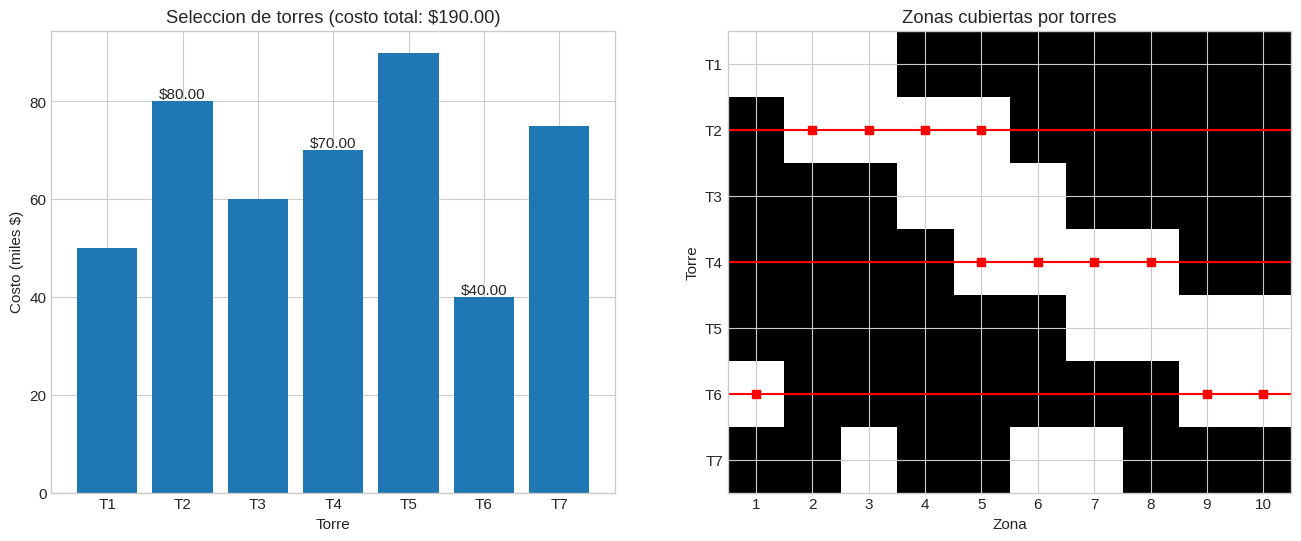

In [22]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura.

    Debe mostrar:
    - Que torres se seleccionaron (con costos)
    - Que zonas cubre cada torre seleccionada

    Args:
        y_opt: np.array (7,)
        costo_opt: float
    """
    fig, ax = plt.subplots(1, 2, figsize=(16,6))

    # Panel 1: torres y costos
    ax[0].bar(nombres_torres_p3, costos_torres_p3)
    ax[0].set_title(f"Seleccion de torres (costo total: ${costo_opt:.2f})")
    ax[0].set_ylabel("Costo (miles $)")
    ax[0].set_xlabel("Torre")
    for i, v in enumerate(costos_torres_p3):
      if y_opt[i] > 0.5:
        ax[0].text(i, v, f"${v:.2f}", ha='center', va='bottom')

    # Panel 2: zonas cubiertas
    ax[1].imshow(cobertura_p3, cmap='gray', aspect='auto')
    #Resaltar zonas cubiertas
    for i, seleccionada in enumerate(y_opt):
        if seleccionada > 0.5:
            zonas_indices = np.where(cobertura_p3[i] ==1)[0]
            ax[1].scatter(zonas_indices, [i]*len(zonas_indices), color='red', marker='s')
            ax[1].axhline(i, color='red')
    ax[1].set_title("Zonas cubiertas por torres")
    ax[1].set_xlabel("Zona")
    ax[1].set_ylabel("Torre")
    ax[1].set_yticks(range(n_torres_p3))
    ax[1].set_yticklabels(nombres_torres_p3)
    ax[1].set_xticks(range(n_zonas_p3))
    ax[1].set_xticklabels(range(1, n_zonas_p3+1))
    ax[1].grid(True)


y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**
Definimos el vector de parámetros desconocidos como:$$\theta = [a, b, c, d]^T$$donde $a, b, c$ y $d$ son los coeficientes que definen la forma de la señal del sensor.

**Funcion objetivo:**
Queremos minimizar la suma de los errores al cuadrado entre las mediciones reales y lo que predice nuestro modelo:$$\min f(a, b, c, d) = \sum_{i=1}^{20} \left( y_{obs,i} - (a \sin(b t_i + c) + d e^{-0.1 t_i}) \right)^2$$

**Restricciones:**
$$a \in [0, 5], \quad b \in [0, 10], \quad c \in [0, 2\pi], \quad d \in [-3, 3]$$

### 4.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
scipy.optimize.differential_evolution (o dual_annealing).

**Justificacion (2-3 oraciones):**
Este es un problema de optimización global "caja negra". Differential evolution es ideal porque mantiene una población de soluciones que exploran todo el espacio, permitiendo encontrar el mínimo global sin necesidad de derivadas

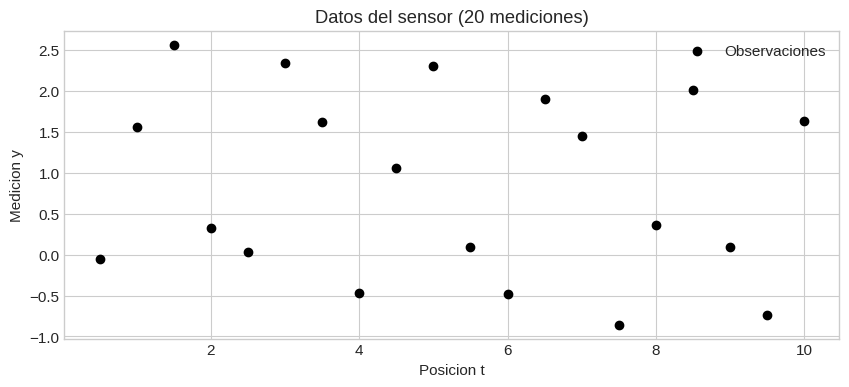

In [23]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [25]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error entre el modelo y las observaciones.

    Args:
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        float -- error total (escalar)
    """
    y_pred = modelo_sensor(t_obs_p4, params)
    return np.sum((y_pred - y_obs_p4)**2)


def resolver_p4():
    """Resuelve el problema de calibracion.

    Returns:
        params_opt: np.array (4,) -- parametros optimos [a, b, c, d]
        error_opt: float -- error minimo encontrado
    """
    respuesta = differential_evolution(objetivo_p4, bounds_p4, seed=2026)
    return respuesta.x, respuesta.fun

Solucion P4:
  a = 1.5089
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error: 0.088386


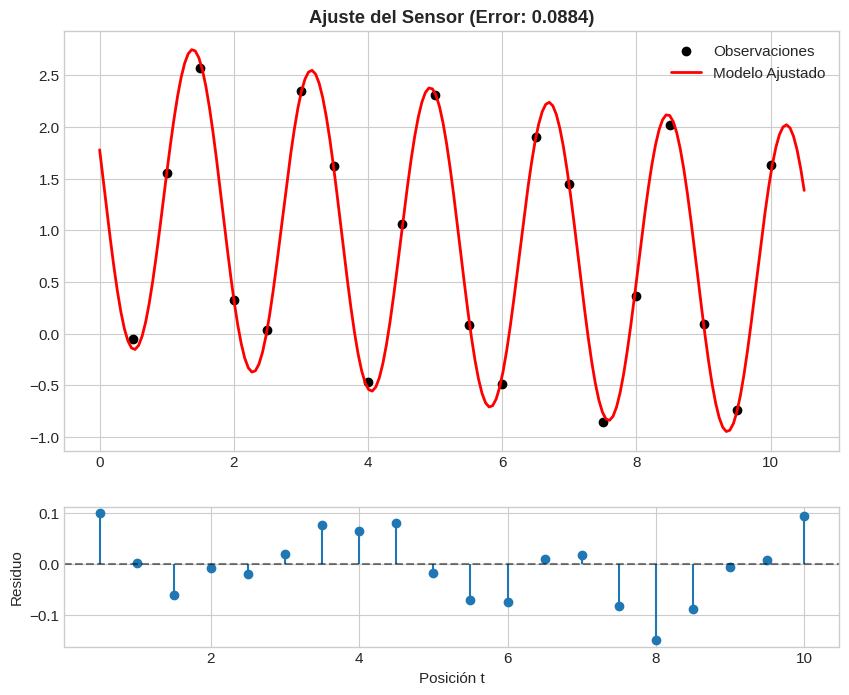

In [27]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """Visualiza el ajuste del modelo a los datos.

    Debe mostrar:
    - Datos observados (puntos)
    - Curva del modelo con parametros encontrados (linea)
    - Residuos (errores punto a punto)

    Args:
        params_opt: np.array (4,)
        error_opt: float
    """
    fig, ax = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Panel superior: Ajuste
    t_fine = np.linspace(0, 10.5, 200)
    y_fit = modelo_sensor(t_fine, params_opt)

    ax[0].scatter(t_obs_p4, y_obs_p4, color="black", label="Observaciones")
    ax[0].plot(t_fine, y_fit, color="red", label="Modelo Ajustado", linewidth=2)
    ax[0].set_title(f"Ajuste del Sensor (Error: {error_opt:.4f})", fontweight='bold')
    ax[0].legend()

    # Panel inferior: Residuos (Errores punto a punto)
    y_pred_obs = modelo_sensor(t_obs_p4, params_opt)
    residuos = y_obs_p4 - y_pred_obs
    ax[1].stem(t_obs_p4, residuos, basefmt=" ")
    ax[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    ax[1].set_ylabel("Residuo")
    ax[1].set_xlabel("Posición t")

params_opt_p4, error_opt_p4 = resolver_p4()

print(f"Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**
Variables binarias ($y_i$): $y_i \in \{0, 1\}$ para $i \in \{1, 2, 3, 4\}$.

Indica si se abre ($1$) o no ($0$) el Centro de Distribución (CD) en la ciudad $i$.

Variables continuas ($X_{ij}$): $X_{ij} \ge 0$ para cada CD $i$ y cada cliente $j \in \{1, \dots, 6\}$.

Representa la cantidad de unidades enviadas desde el CD $i$ al cliente $j$.

**Funcion objetivo:**
Minimizar el costo total (Costo Fijo + Costo Variable de Envío):

$$\min Z = \sum_{i=1}^{4} \text{CostoFijo}_i \cdot y_i + \sum_{i=1}^{4} \sum_{j=1}^{6} \text{CostoEnvio}_{ij} \cdot X_{ij}$$

**Restricciones:**

Lo que recibe cada cliente $j$ de todos los CDs debe ser igual a su demanda ($D_j$):

$$\sum_{i=1}^{4} X_{ij} = D_j, \quad \forall j \in \{1, \dots, 6\}$$

Lo que envía cada CD $i$ no puede superar su capacidad ($Cap_i$). Además, si el CD está cerrado ($y_i = 0$), no puede enviar nada:

$$\sum_{j=1}^{6} X_{ij} \le Cap_i \cdot y_i, \quad \forall i \in \{1, \dots, 4\}$$

$X_{ij} \ge 0$

### 5.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

In [28]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [29]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    """Calcula el costo total: costos fijos + costos de envio.

    Args:
        y: np.array (4,) -- 1 si el CD esta abierto, 0 si no
        X: np.array (4, 6) -- unidades enviadas de CD i a cliente j

    Returns:
        float -- costo total
    """
    costo_fijo = np.dot(costos_fijos_p5, y)
    costo_envio = np.sum(costos_envio_p5 * X)
    return costo_fijo + costo_envio


def verificar_p5(y, X):
    """Verifica si la solucion cumple todas las restricciones.

    Args:
        y: np.array (4,) -- apertura de CDs
        X: np.array (4, 6) -- envios

    Returns:
        dict con:
            'factible': bool
            'demanda_cumplida': np.array (6,) -- unidades recibidas por cada cliente
            'capacidad_usada': np.array (4,) -- capacidad usada por cada CD
    """
    demanda_cumplida = np.sum(X, axis=0)
    capacidad_usada = np.sum(X, axis=1)
    # Validar cumplimiento de demanda y limites de capacidad
    c1 = np.all(np.abs(demanda_cumplida - demandas_p5) < 0.0001)
    c2 = np.all(capacidad_usada <= (capacidades_p5 * y) + 0.0001)
    factible = c1 and c2
    return {
        'factible': factible,
        'demanda_cumplida': demanda_cumplida,
        'capacidad_usada': capacidad_usada
    }

def resolver_p5():
    """Resuelve el problema de red de distribucion.

    Returns:
        y_opt: np.array (4,) -- 1 si el CD se abre, 0 si no
        X_opt: np.array (4, 6) -- envios optimos
        costo_opt: float -- costo total minimo
    """
    n_vars = n_cds_p5 + (n_cds_p5 * n_clientes_p5)
    c = np.concatenate([costos_fijos_p5, costos_envio_p5.flatten()])
    A_list, lb_list, ub_list = [], [], []

    # Restriccion de demanda para cada cliente
    for j in range(n_clientes_p5):
        fila = np.zeros(n_vars)
        for i in range(n_cds_p5):
            fila[n_cds_p5 + i * n_clientes_p5 + j] = 1
        A_list.append(fila); lb_list.append(demandas_p5[j]); ub_list.append(demandas_p5[j])

    # Restriccion de capacidad para cada centro
    for i in range(n_cds_p5):
        fila = np.zeros(n_vars)
        fila[i] = -capacidades_p5[i]
        for j in range(n_clientes_p5):
            fila[n_cds_p5 + i * n_clientes_p5 + j] = 1
        A_list.append(fila); lb_list.append(-np.inf); ub_list.append(0)

    constraints = LinearConstraint(A_list, lb_list, ub_list)
    integrality = np.concatenate([np.ones(n_cds_p5), np.zeros(n_cds_p5 * n_clientes_p5)])
    bounds = Bounds(0, np.inf)
    res = milp(c, constraints=constraints, integrality=integrality, bounds=bounds)
    y_opt = np.round(res.x[:n_cds_p5])
    X_opt = res.x[n_cds_p5:].reshape(n_cds_p5, n_clientes_p5)

    return y_opt, X_opt, res.fun

Solucion P5:
  CDMX: ABIERTO (480/600 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C4: 80 unidades
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 70 unidades
    -> Cliente C5: 100 unidades
    -> Cliente C6: 180 unidades
Costo total: $5130k
Factible: True


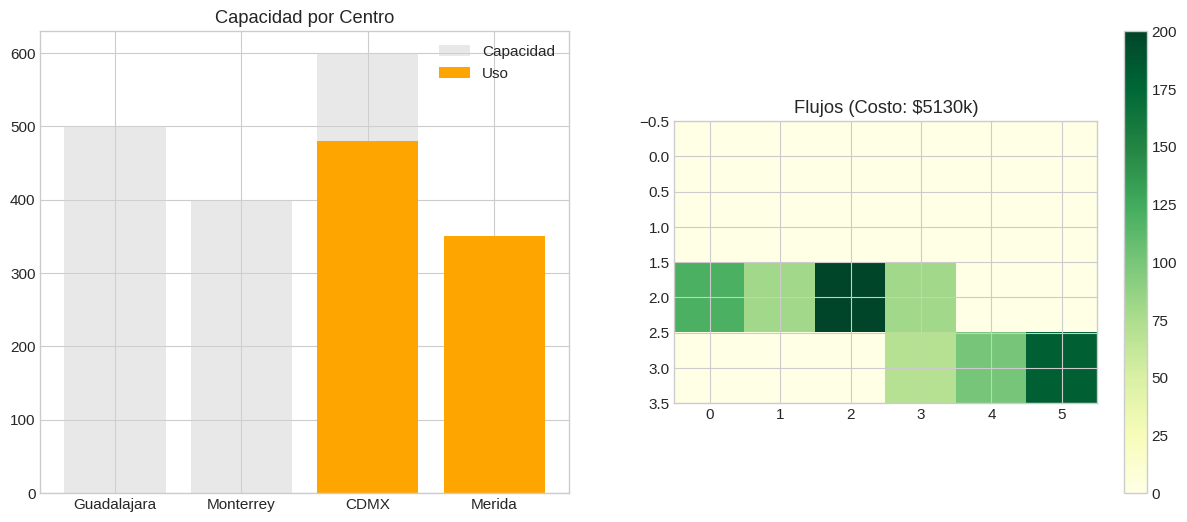

In [30]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    """Visualiza la red de distribucion.

    Debe mostrar:
    - Que CDs estan abiertos (con capacidad usada vs disponible)
    - Flujo de envios: de cada CD a cada cliente

    Args:
        y_opt: np.array (4,)
        X_opt: np.array (4, 6)
        costo_opt: float
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    cap_usada = X_opt.sum(axis=1)
    ax[0].bar(ciudades_p5, capacidades_p5, color='lightgray', alpha=0.5, label='Capacidad')
    ax[0].bar(ciudades_p5, cap_usada, color='orange', label='Uso')
    ax[0].set_title("Capacidad por Centro")
    ax[0].legend()

    im = ax[1].imshow(X_opt, cmap='YlGn')
    ax[1].set_title(f"Flujos (Costo: ${costo_opt:.0f}k)")
    plt.colorbar(im, ax=ax[1])

y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print(f"Solucion P5:")
for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
    if abierto > 0.5:
        cap_usada = X_opt_p5[i].sum()
        print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
        for j in range(n_clientes_p5):
            if X_opt_p5[i, j] > 0.1:
                print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)